# ML classification: CC vs NC, then flavour

Two classification tasks, both done with the same four models: **Logistic Regression, Random Forest, XGBoost, LightGBM**.

**Task A: CC vs NC** -- binary. Did the neutrino interaction produce a charged lepton?
**Task B: Flavour within CC** -- 3-class. Was the incoming neutrino νe, νμ, or ντ?

**Important:** features are **detector observables only** -- no MC truth. Using truth-derived features (e.g. `n_primaries`, `leading_lepton_pdg`) would leak the target. The model has to figure out CC/NC and flavour from raw hit-pattern statistics alone, exactly as it would on real data.

**Splits:** stratified 80/20 split + 5-fold stratified CV (the latter is more robust at this sample size).

**Metrics:** Accuracy, Precision, Recall, F1 (macro for multi-class), ROC-AUC, PR-AUC.

**Plots:** combined ROC curves, combined PR curves, confusion matrices.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, classification_report)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42

df = pd.read_csv('dataset.csv')
print(f'Loaded dataset.csv: {len(df):,} rows')

Loaded dataset.csv: 1,000 rows


## 1. Choose the feature set

Detector observables ONLY. Anything derived from MC truth is excluded.

In [2]:
FEATURES = [
    'n_hits', 'n_hits_w', 'n_hits_v', 'n_hits_u',
    'total_adc', 'mean_adc', 'max_adc',
    'drift_range', 'drift_std',
    'channel_range_w', 'channel_range_u', 'channel_range_v',
    'hit_density',
    'n_points_raw', 'n_points_filtered',     # detector-derived (not truth)
]

X_all = df[FEATURES].copy().fillna(0).astype(float)
print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'X_all shape: {X_all.shape}')

Features (15): ['n_hits', 'n_hits_w', 'n_hits_v', 'n_hits_u', 'total_adc', 'mean_adc', 'max_adc', 'drift_range', 'drift_std', 'channel_range_w', 'channel_range_u', 'channel_range_v', 'hit_density', 'n_points_raw', 'n_points_filtered']
X_all shape: (1000, 15)


## 2. Model factory

Same four models for both tasks; for binary tasks pass `scale_pos_weight`, for multi-class use `class_weight='balanced'`.

In [3]:
def make_models_binary(n_pos, n_neg, seed=RANDOM_STATE):
    ratio = n_neg / max(n_pos, 1)
    return {
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                                       random_state=seed))]),
        'Random Forest': RandomForestClassifier(
            n_estimators=300, class_weight='balanced',
            n_jobs=-1, random_state=seed),
        'XGBoost': XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.1,
            scale_pos_weight=ratio, eval_metric='logloss',
            n_jobs=-1, random_state=seed),
        'LightGBM': LGBMClassifier(
            n_estimators=300, learning_rate=0.1,
            scale_pos_weight=ratio, n_jobs=-1,
            random_state=seed, verbosity=-1),
    }

def make_models_multi(seed=RANDOM_STATE):
    return {
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                                       random_state=seed))]),
        'Random Forest': RandomForestClassifier(
            n_estimators=300, class_weight='balanced',
            n_jobs=-1, random_state=seed),
        'XGBoost': XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.1,
            objective='multi:softprob', eval_metric='mlogloss',
            n_jobs=-1, random_state=seed),
        'LightGBM': LGBMClassifier(
            n_estimators=300, learning_rate=0.1, objective='multiclass',
            class_weight='balanced', n_jobs=-1,
            random_state=seed, verbosity=-1),
    }

MODEL_COLOURS = {
    'Logistic Regression': '#E07B7B', 'Random Forest': '#2D6A9F',
    'XGBoost': '#3FA34D', 'LightGBM': '#F2A03F',
}

# Task A -- CC vs NC (binary)

In [4]:
y_cc = df['is_cc'].astype(int)
X_cc = X_all

X_tr, X_te, y_tr, y_te = train_test_split(X_cc, y_cc, test_size=0.2,
                                          stratify=y_cc, random_state=RANDOM_STATE)
n_pos, n_neg = int(y_tr.sum()), int(len(y_tr) - y_tr.sum())
print(f'Train: {len(y_tr)}  ({n_pos} CC, {n_neg} NC)')
print(f'Test : {len(y_te)}  ({y_te.sum()} CC, {len(y_te)-y_te.sum()} NC)')

models = make_models_binary(n_pos, n_neg)
results_cc = {}
for name, m in models.items():
    m.fit(X_tr, y_tr)
    y_pred = m.predict(X_te)
    y_score = m.predict_proba(X_te)[:,1]
    results_cc[name] = {
        'model': m,
        'y_true': y_te.values, 'y_pred': y_pred, 'y_score': y_score,
        'metrics': {
            'Accuracy':  accuracy_score(y_te, y_pred),
            'Precision': precision_score(y_te, y_pred, zero_division=0),
            'Recall':    recall_score(y_te, y_pred, zero_division=0),
            'F1':        f1_score(y_te, y_pred, zero_division=0),
            'ROC-AUC':   roc_auc_score(y_te, y_score),
            'PR-AUC':    average_precision_score(y_te, y_score),
        }
    }

summary_cc = pd.DataFrame({n: r['metrics'] for n, r in results_cc.items()}).T.round(4)
print('\nCC vs NC -- single 80/20 split:'); display(summary_cc)

Train: 800  (434 CC, 366 NC)
Test : 200  (109 CC, 91 NC)



CC vs NC -- single 80/20 split:


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.700,0.7168,0.7431,0.7297,0.7429,0.7482
Random Forest,0.805,0.7652,0.9266,0.8382,0.8436,0.8218
XGBoost,0.755,0.7459,0.8349,0.7879,0.8169,0.7983
LightGBM,0.765,0.7422,0.8716,0.8017,0.8221,0.7888


### CC vs NC -- 5-fold cross-validation

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_metrics = {n: {m:[] for m in ['Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC']}
              for n in models}

for fold, (tr_i, te_i) in enumerate(skf.split(X_cc, y_cc)):
    X_tr_f, X_te_f = X_cc.iloc[tr_i], X_cc.iloc[te_i]
    y_tr_f, y_te_f = y_cc.iloc[tr_i], y_cc.iloc[te_i]
    np_, nn_ = int(y_tr_f.sum()), int(len(y_tr_f) - y_tr_f.sum())
    for name, m in make_models_binary(np_, nn_).items():
        m.fit(X_tr_f, y_tr_f)
        y_pred = m.predict(X_te_f)
        y_score = m.predict_proba(X_te_f)[:,1]
        cv_metrics[name]['Accuracy'].append(accuracy_score(y_te_f, y_pred))
        cv_metrics[name]['Precision'].append(precision_score(y_te_f, y_pred, zero_division=0))
        cv_metrics[name]['Recall'].append(recall_score(y_te_f, y_pred, zero_division=0))
        cv_metrics[name]['F1'].append(f1_score(y_te_f, y_pred, zero_division=0))
        cv_metrics[name]['ROC-AUC'].append(roc_auc_score(y_te_f, y_score))
        cv_metrics[name]['PR-AUC'].append(average_precision_score(y_te_f, y_score))

cv_summary_cc = pd.DataFrame({n: {m: f'{np.mean(v):.3f} ± {np.std(v):.3f}'
                                  for m,v in d.items()}
                              for n,d in cv_metrics.items()}).T
print('CC vs NC -- 5-fold CV (mean ± std):'); display(cv_summary_cc)

CC vs NC -- 5-fold CV (mean ± std):


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.692 ± 0.022,0.732 ± 0.022,0.683 ± 0.038,0.706 ± 0.025,0.751 ± 0.014,0.743 ± 0.025
Random Forest,0.812 ± 0.024,0.773 ± 0.017,0.926 ± 0.029,0.842 ± 0.021,0.852 ± 0.026,0.824 ± 0.034
XGBoost,0.790 ± 0.028,0.771 ± 0.025,0.873 ± 0.028,0.819 ± 0.024,0.839 ± 0.028,0.805 ± 0.039
LightGBM,0.790 ± 0.038,0.777 ± 0.035,0.862 ± 0.029,0.817 ± 0.032,0.842 ± 0.037,0.802 ± 0.054


### CC vs NC -- combined ROC and PR curves

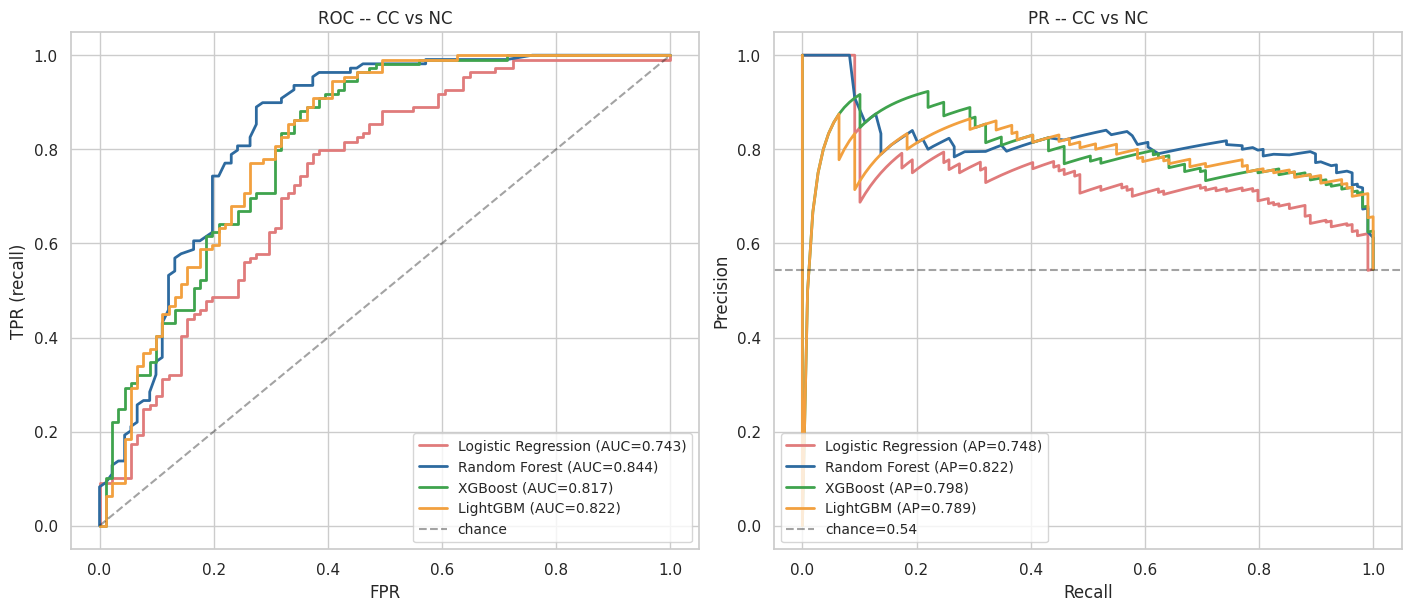

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for name, r in results_cc.items():
    fpr, tpr, _ = roc_curve(r['y_true'], r['y_score'])
    p, rc, _    = precision_recall_curve(r['y_true'], r['y_score'])
    axes[0].plot(fpr, tpr, lw=2, color=MODEL_COLOURS[name],
                 label=f"{name} (AUC={r['metrics']['ROC-AUC']:.3f})")
    axes[1].plot(rc, p, lw=2, color=MODEL_COLOURS[name],
                 label=f"{name} (AP={r['metrics']['PR-AUC']:.3f})")
axes[0].plot([0,1],[0,1],'k--',alpha=0.4,label='chance')
axes[1].axhline(y_cc.mean(),ls='--',color='k',alpha=0.4,label=f'chance={y_cc.mean():.2f}')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR (recall)'); axes[0].set_title('ROC -- CC vs NC')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('PR -- CC vs NC')
for ax in axes: ax.legend(loc='lower left' if ax==axes[1] else 'lower right', fontsize=10)

### CC vs NC -- confusion matrices

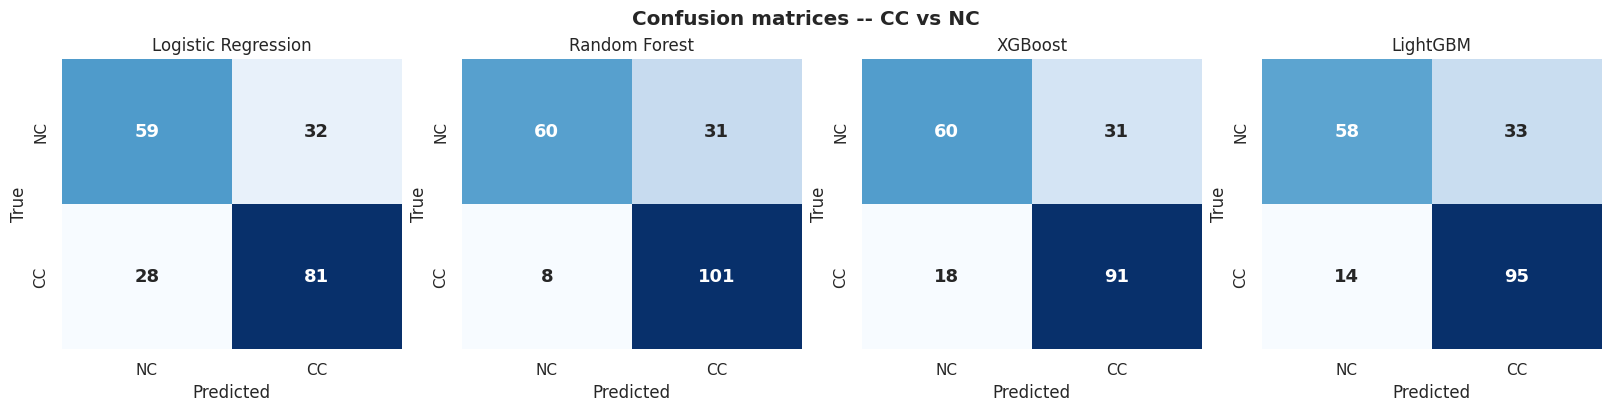

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
for ax, (name, r) in zip(axes, results_cc.items()):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['NC','CC'], yticklabels=['NC','CC'],
                annot_kws={'fontsize':13,'fontweight':'bold'})
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
fig.suptitle('Confusion matrices -- CC vs NC', fontweight='bold');

### CC vs NC -- classification reports

In [8]:
for name, r in results_cc.items():
    print(f'=== {name} ===')
    print(classification_report(r['y_true'], r['y_pred'],
                                target_names=['NC','CC'], digits=3))

=== Logistic Regression ===
              precision    recall  f1-score   support

          NC      0.678     0.648     0.663        91
          CC      0.717     0.743     0.730       109

    accuracy                          0.700       200
   macro avg      0.697     0.696     0.696       200
weighted avg      0.699     0.700     0.699       200

=== Random Forest ===
              precision    recall  f1-score   support

          NC      0.882     0.659     0.755        91
          CC      0.765     0.927     0.838       109

    accuracy                          0.805       200
   macro avg      0.824     0.793     0.796       200
weighted avg      0.818     0.805     0.800       200

=== XGBoost ===
              precision    recall  f1-score   support

          NC      0.769     0.659     0.710        91
          CC      0.746     0.835     0.788       109

    accuracy                          0.755       200
   macro avg      0.758     0.747     0.749       200
weighted

# Task B -- Flavour classification (CC events only)

Three-class: νe / νμ / ντ. Only CC events used (NC has no charged lepton, so flavour identification from detector observables is meaningless).

In [9]:
df_cc = df[df['is_cc']].reset_index(drop=True)
le = LabelEncoder()
y_fl = le.fit_transform(df_cc['nu_flavour'])
X_fl = df_cc[FEATURES].fillna(0).astype(float)
print(f'CC events: {len(df_cc)}')
print(f'Class counts: {dict(zip(le.classes_, np.bincount(y_fl)))}')

X_tr, X_te, y_tr, y_te = train_test_split(X_fl, y_fl, test_size=0.2,
                                          stratify=y_fl, random_state=RANDOM_STATE)

results_fl = {}
for name, m in make_models_multi().items():
    m.fit(X_tr, y_tr)
    y_pred = m.predict(X_te)
    y_score = m.predict_proba(X_te)
    results_fl[name] = {
        'model': m, 'y_true': y_te, 'y_pred': y_pred, 'y_score': y_score,
        'metrics': {
            'Accuracy':       accuracy_score(y_te, y_pred),
            'Precision macro': precision_score(y_te, y_pred, average='macro', zero_division=0),
            'Recall macro':    recall_score(y_te, y_pred, average='macro', zero_division=0),
            'F1 macro':        f1_score(y_te, y_pred, average='macro', zero_division=0),
            'ROC-AUC OvR':     roc_auc_score(y_te, y_score, multi_class='ovr', average='macro'),
        }
    }
summary_fl = pd.DataFrame({n: r['metrics'] for n, r in results_fl.items()}).T.round(4)
print('\nFlavour -- single 80/20 split:'); display(summary_fl)

CC events: 543
Class counts: {'nue': np.int64(300), 'numu': np.int64(229), 'nutau': np.int64(14)}



Flavour -- single 80/20 split:


,Accuracy,Precision macro,Recall macro,F1 macro,ROC-AUC OvR
Logistic Regression,0.5872,0.4344,0.3928,0.4119,0.6227
Random Forest,0.6330,0.4212,0.4205,0.4149,0.5779
XGBoost,0.6606,0.4456,0.4372,0.4313,0.6889
LightGBM,0.6422,0.4242,0.4295,0.4241,0.7011


### Flavour -- 5-fold cross-validation

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_fl = {n: {m:[] for m in ['Accuracy','Precision macro','Recall macro','F1 macro','ROC-AUC OvR']}
         for n in results_fl}

for fold, (tr_i, te_i) in enumerate(skf.split(X_fl, y_fl)):
    X_tr_f, X_te_f = X_fl.iloc[tr_i], X_fl.iloc[te_i]
    y_tr_f, y_te_f = y_fl[tr_i], y_fl[te_i]
    for name, m in make_models_multi().items():
        m.fit(X_tr_f, y_tr_f)
        y_pred  = m.predict(X_te_f)
        y_score = m.predict_proba(X_te_f)
        cv_fl[name]['Accuracy'].append(accuracy_score(y_te_f, y_pred))
        cv_fl[name]['Precision macro'].append(precision_score(y_te_f, y_pred, average='macro', zero_division=0))
        cv_fl[name]['Recall macro'].append(recall_score(y_te_f, y_pred, average='macro', zero_division=0))
        cv_fl[name]['F1 macro'].append(f1_score(y_te_f, y_pred, average='macro', zero_division=0))
        try:
            cv_fl[name]['ROC-AUC OvR'].append(
                roc_auc_score(y_te_f, y_score, multi_class='ovr', average='macro'))
        except ValueError:
            cv_fl[name]['ROC-AUC OvR'].append(np.nan)

cv_summary_fl = pd.DataFrame({n:{m:f'{np.nanmean(v):.3f} ± {np.nanstd(v):.3f}'
                                 for m,v in d.items()}
                              for n,d in cv_fl.items()}).T
print('Flavour -- 5-fold CV:'); display(cv_summary_fl)

Flavour -- 5-fold CV:


,Accuracy,Precision macro,Recall macro,F1 macro,ROC-AUC OvR
Logistic Regression,0.523 ± 0.025,0.440 ± 0.018,0.420 ± 0.039,0.404 ± 0.009,0.613 ± 0.062
Random Forest,0.716 ± 0.014,0.484 ± 0.022,0.478 ± 0.007,0.474 ± 0.007,0.668 ± 0.078
XGBoost,0.687 ± 0.017,0.458 ± 0.016,0.461 ± 0.012,0.456 ± 0.012,0.689 ± 0.024
LightGBM,0.702 ± 0.028,0.469 ± 0.023,0.473 ± 0.017,0.469 ± 0.018,0.671 ± 0.064


### Flavour -- combined ROC and PR curves (one-vs-rest, macro-averaged)

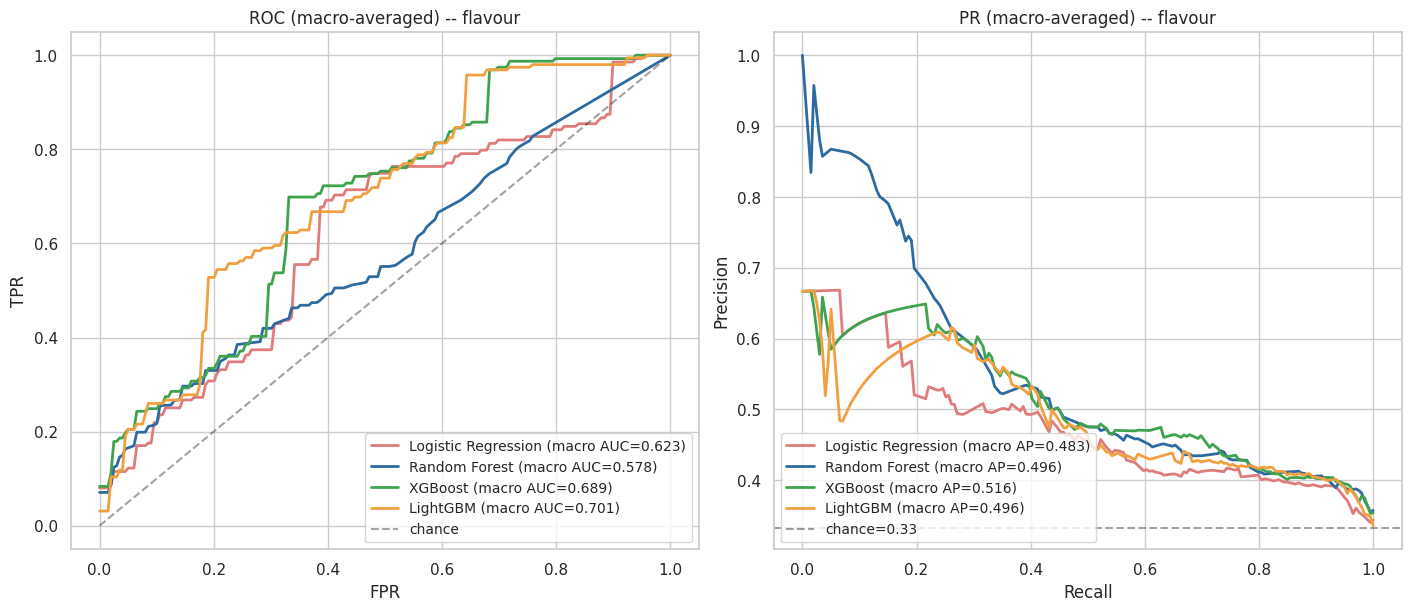

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
n_classes = len(le.classes_)

for name, r in results_fl.items():
    # Macro-average ROC and PR over the 3 classes (OvR)
    y_t = r['y_true']; y_s = r['y_score']
    # ROC: collect per-class FPR/TPR and average at common thresholds
    mean_fpr = np.linspace(0, 1, 200)
    tpr_acc = []
    for c in range(n_classes):
        fpr_c, tpr_c, _ = roc_curve((y_t == c).astype(int), y_s[:, c])
        tpr_acc.append(np.interp(mean_fpr, fpr_c, tpr_c))
    mean_tpr = np.mean(tpr_acc, axis=0)
    auc_macro = r['metrics']['ROC-AUC OvR']
    axes[0].plot(mean_fpr, mean_tpr, lw=2, color=MODEL_COLOURS[name],
                 label=f"{name} (macro AUC={auc_macro:.3f})")

    # PR: macro-average
    mean_rec = np.linspace(0, 1, 200)
    prec_acc = []
    for c in range(n_classes):
        p_c, rc_c, _ = precision_recall_curve((y_t == c).astype(int), y_s[:, c])
        # invert so recall axis is monotonic
        order = np.argsort(rc_c)
        prec_acc.append(np.interp(mean_rec, rc_c[order], p_c[order]))
    mean_prec = np.mean(prec_acc, axis=0)
    ap_macro = np.mean([average_precision_score((y_t == c).astype(int), y_s[:, c])
                        for c in range(n_classes)])
    axes[1].plot(mean_rec, mean_prec, lw=2, color=MODEL_COLOURS[name],
                 label=f"{name} (macro AP={ap_macro:.3f})")

axes[0].plot([0,1],[0,1],'k--',alpha=0.4,label='chance')
axes[1].axhline(1/n_classes, ls='--', color='k', alpha=0.4, label=f'chance={1/n_classes:.2f}')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC (macro-averaged) -- flavour')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('PR (macro-averaged) -- flavour')
for ax in axes: ax.legend(loc='lower left' if ax==axes[1] else 'lower right', fontsize=10)

### Flavour -- confusion matrices

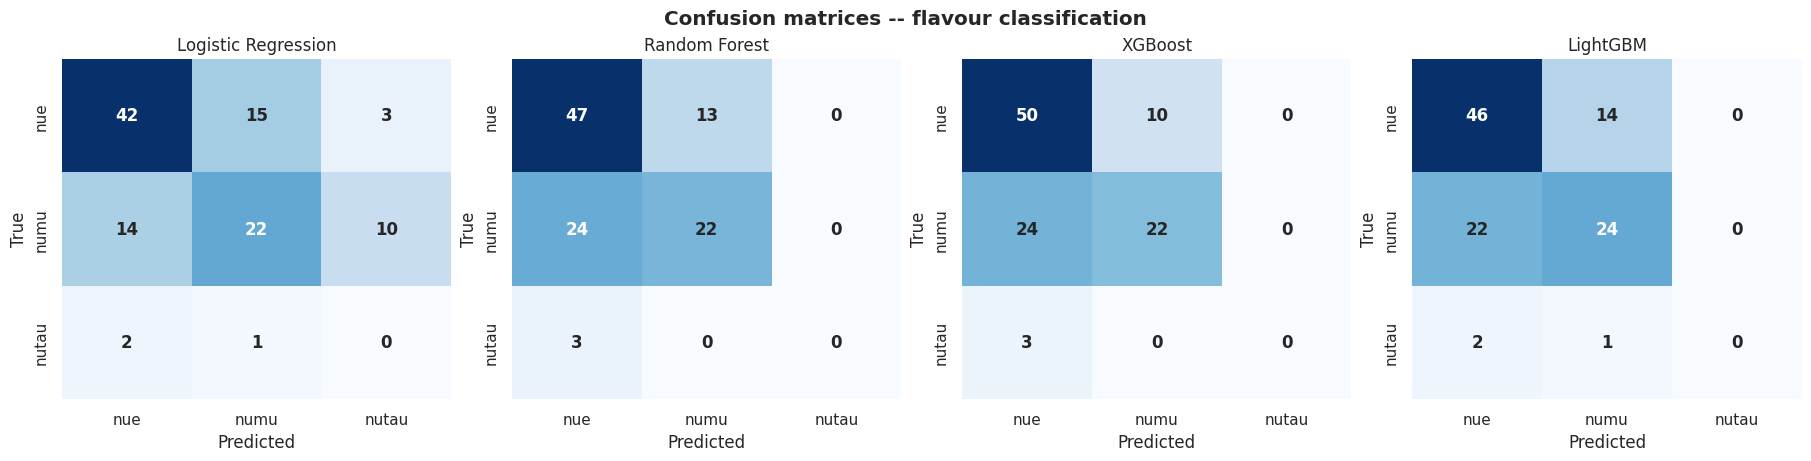

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), constrained_layout=True)
for ax, (name, r) in zip(axes, results_fl.items()):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                annot_kws={'fontsize':12,'fontweight':'bold'})
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
fig.suptitle('Confusion matrices -- flavour classification', fontweight='bold');

### Flavour -- classification reports

In [13]:
for name, r in results_fl.items():
    print(f'=== {name} ===')
    print(classification_report(r['y_true'], r['y_pred'],
                                target_names=le.classes_, digits=3))

=== Logistic Regression ===
              precision    recall  f1-score   support

         nue      0.724     0.700     0.712        60
        numu      0.579     0.478     0.524        46
       nutau      0.000     0.000     0.000         3

    accuracy                          0.587       109
   macro avg      0.434     0.393     0.412       109
weighted avg      0.643     0.587     0.613       109

=== Random Forest ===
              precision    recall  f1-score   support

         nue      0.635     0.783     0.701        60
        numu      0.629     0.478     0.543        46
       nutau      0.000     0.000     0.000         3

    accuracy                          0.633       109
   macro avg      0.421     0.421     0.415       109
weighted avg      0.615     0.633     0.615       109

=== XGBoost ===
              precision    recall  f1-score   support

         nue      0.649     0.833     0.730        60
        numu      0.688     0.478     0.564        46
       nu

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packag

## Feature importance (tree-based models, both tasks)

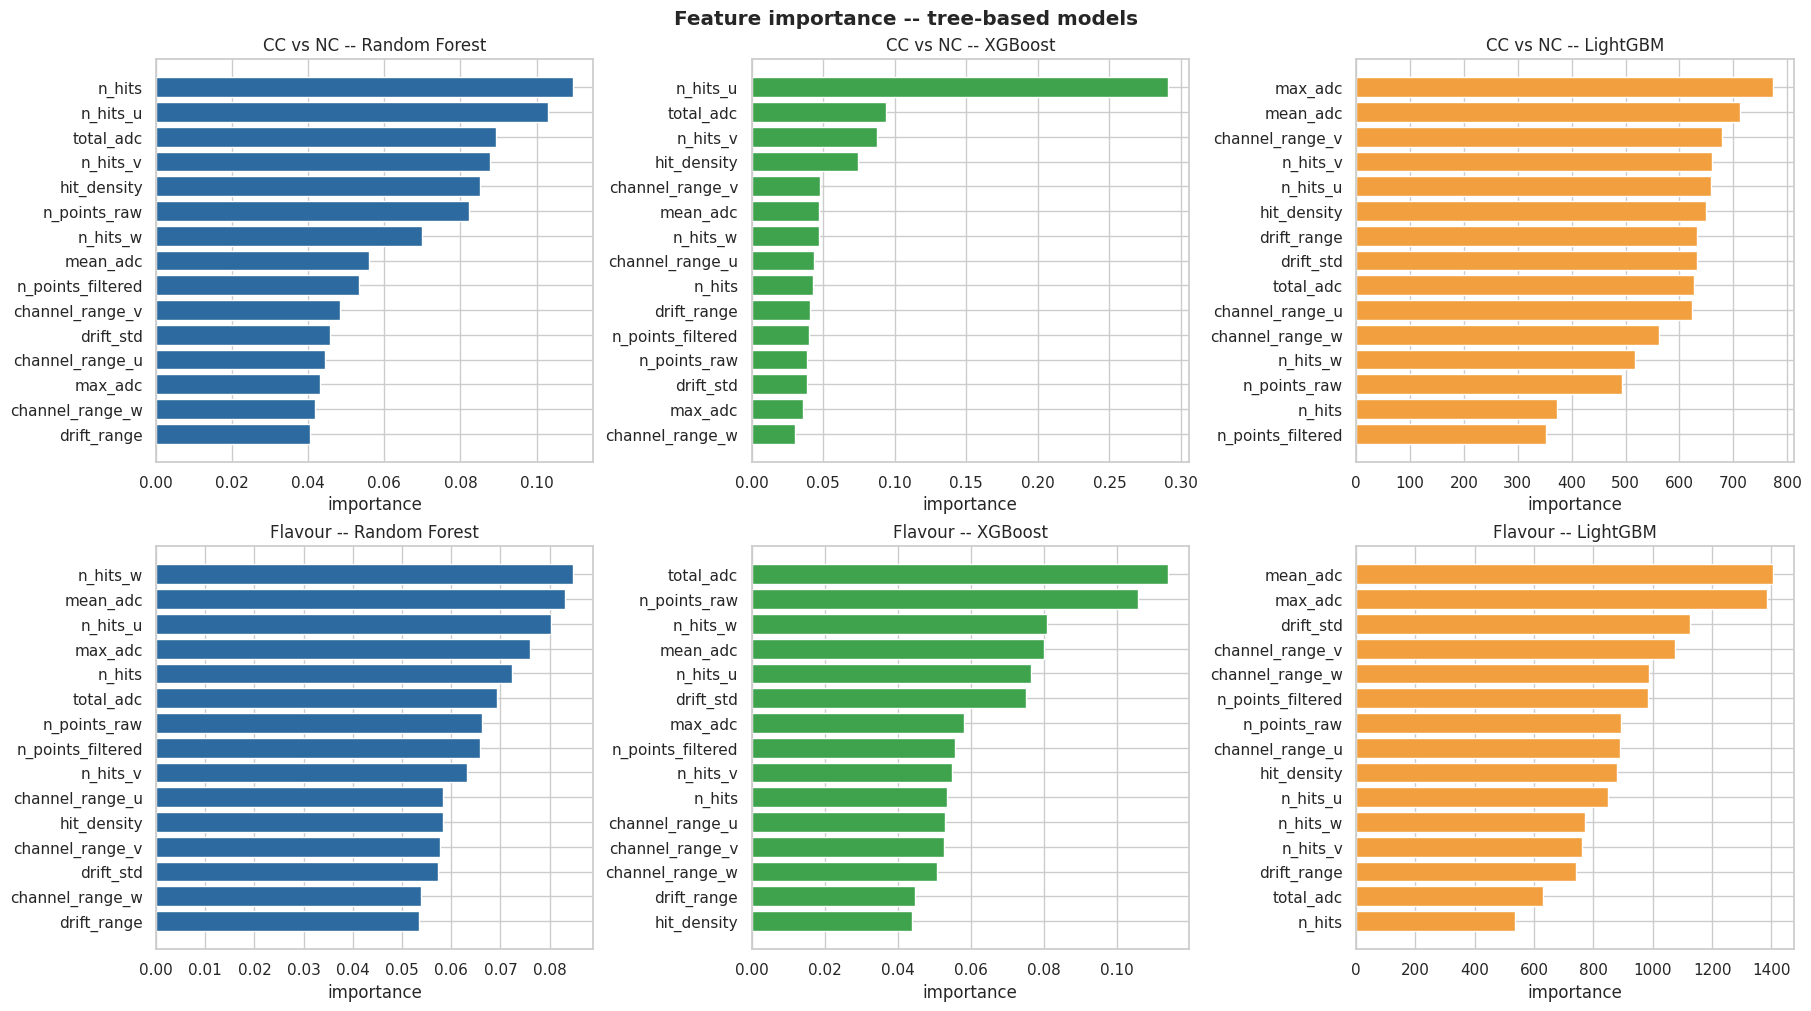

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
tree_names = ['Random Forest', 'XGBoost', 'LightGBM']

for col, name in enumerate(tree_names):
    if name not in results_cc: continue
    imp = results_cc[name]['model'].feature_importances_
    order = np.argsort(imp)[::-1][:15]
    axes[0, col].barh([FEATURES[i] for i in order[::-1]], imp[order[::-1]],
                       color=MODEL_COLOURS[name])
    axes[0, col].set_title(f'CC vs NC -- {name}')
    axes[0, col].set_xlabel('importance')

    imp = results_fl[name]['model'].feature_importances_
    order = np.argsort(imp)[::-1][:15]
    axes[1, col].barh([FEATURES[i] for i in order[::-1]], imp[order[::-1]],
                       color=MODEL_COLOURS[name])
    axes[1, col].set_title(f'Flavour -- {name}')
    axes[1, col].set_xlabel('importance')

fig.suptitle('Feature importance -- tree-based models', fontweight='bold');

## Honest take on the results

**CC vs NC** is a real, well-defined classification task and the tabular models do reasonably well -- typically 80–90% accuracy on a balanced problem. The signal lives in the hit count, the drift range, and the channel range: CC events have a long lepton track that elongates the event, NC events are more spatially compact.

**Flavour classification** is much harder for a tabular model. Distinguishing νe (electromagnetic shower) from νμ (long muon track) is the easy direction; distinguishing νμ from ντ from event-summary statistics alone is genuinely hard because the τ decays quickly into a final state that can look like νμ or νe interactions. Expect macro F1 in the 0.5–0.7 range for a tabular model on this task.

**Recommended next step:** a CNN on the 2D wire-plane images (one channel per plane). The spatial structure -- track length, shower opening angle, kinks -- is precisely what convolutional filters learn to recognise, and it's exactly the information that summary statistics throw away.